In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plot style globally
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# Path to the folder containing all CSV files
data_folder = 'data/'

# List all CSV files in the folder
all_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
print(f'Found {len(all_files)} CSV files: {all_files}')

# Read each file and combine into one DataFrame
df_list = []
for file in all_files:
    filepath = os.path.join(data_folder, file)
    df_month = pd.read_csv(filepath)
    df_list.append(df_month)

# Concatenate (stack) all DataFrames vertically
df = pd.concat(df_list, ignore_index=True)

print(f'Combined DataFrame shape: {df.shape}')
print(f'Total rows: {len(df):,}')

df.head(3)

Found 12 CSV files: ['Sales_April_2019.csv', 'Sales_August_2019.csv', 'Sales_December_2019.csv', 'Sales_February_2019.csv', 'Sales_January_2019.csv', 'Sales_July_2019.csv', 'Sales_June_2019.csv', 'Sales_March_2019.csv', 'Sales_May_2019.csv', 'Sales_November_2019.csv', 'Sales_October_2019.csv', 'Sales_September_2019.csv']
Combined DataFrame shape: (186850, 6)
Total rows: 186,850


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"


In [3]:
# Basic information about the dataset
print('=== Shape ===')
print(df.shape)

print('\n=== Column Data Types ===')
print(df.dtypes)

print('\n=== Missing Values per Column ===')
print(df.isnull().sum())

print('\n=== Number of Duplicate Rows ===')
print(df.duplicated().sum())

print('\n=== Basic Statistics ===')
print(df.describe())

=== Shape ===
(186850, 6)

=== Column Data Types ===
Order ID            str
Product             str
Quantity Ordered    str
Price Each          str
Order Date          str
Purchase Address    str
dtype: object

=== Missing Values per Column ===
Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

=== Number of Duplicate Rows ===
1162

=== Basic Statistics ===
        Order ID               Product Quantity Ordered Price Each  \
count     186305                186305           186305     186305   
unique    178438                    20               10         24   
top     Order ID  USB-C Charging Cable                1      11.95   
freq         355                 21903           168552      21903   

        Order Date  Purchase Address  
count       186305            186305  
unique      142396            140788  
top     Order Date  Purchase Address  
freq           355       

In [4]:
# Step 4a: Remove rows where ALL values are NaN (blank separator rows)
df.dropna(how='all', inplace=True)
print(f'After removing all-NaN rows: {len(df):,} rows')

# Step 4b: Some rows have the header text repeated inside the data
# Example: Order ID column contains 'Order ID' as a value — remove these
df = df[df['Order ID'] != 'Order ID']
print(f'After removing repeated headers: {len(df):,} rows')

# Step 4c: Remove any remaining NaN rows
df.dropna(inplace=True)
print(f'After dropping remaining NaN rows: {len(df):,} rows')

# Step 4d: Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f'After removing duplicates: {len(df):,} rows')

# Step 4e: Fix data types
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])
df['Order Date'] = pd.to_datetime(df['Order Date'])

print('\nData types after cleaning:')
print(df.dtypes)

After removing all-NaN rows: 186,305 rows
After removing repeated headers: 185,950 rows
After dropping remaining NaN rows: 185,950 rows
After removing duplicates: 185,686 rows

Data types after cleaning:
Order ID                       str
Product                        str
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[us]
Purchase Address               str
dtype: object


In [5]:
# New column 1: Sales = Quantity * Price
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

print('Sales column created. Sample values:')
print(df['Sales'].head())

# New column 2: Month number (1=January, 12=December)
df['Month'] = df['Order Date'].dt.month

# New column 3: Month name for readable charts
month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

df['Month Name'] = df['Month'].map(month_names)

# New column 4: Hour of the day (0–23)
df['Hour'] = df['Order Date'].dt.hour

# New column 5: City (extracted from Purchase Address)
# Address format: '136 Church St, New York City, NY 10001'
# The city is the second part after splitting by comma
df['City'] = df['Purchase Address'].apply(
    lambda x: x.split(',')[1].strip()
)

# Verify all new columns
print(
    df[
        ['Order Date', 'Month', 'Month Name',
         'Hour', 'City', 'Sales']
    ].head(3)
)

Sales column created. Sample values:
0     23.90
2     99.99
3    600.00
4     11.99
5     11.99
Name: Sales, dtype: float64
           Order Date  Month Month Name  Hour         City   Sales
0 2019-04-19 08:46:00      4        Apr     8       Dallas   23.90
2 2019-04-07 22:30:00      4        Apr    22       Boston   99.99
3 2019-04-12 14:38:00      4        Apr    14  Los Angeles  600.00


In [6]:
# Q1: Which month had the highest sales?
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

monthly_sales['Month Name'] = monthly_sales['Month'].map(month_names)

monthly_sales = monthly_sales.sort_values('Month')

print('Monthly Sales:')
print(
    monthly_sales[
        ['Month Name', 'Sales']
    ].to_string(index=False)
)

best_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax(),
    'Month Name'
]

best_sales = monthly_sales['Sales'].max()

print(
    f'\nBest month: {best_month} '
    f'with ${best_sales:,.2f} in sales'
)

Monthly Sales:
Month Name      Sales
       Jan 1821413.16
       Feb 2200078.08
       Mar 2804973.35
       Apr 3389217.98
       May 3150616.23
       Jun 2576280.15
       Jul 2646461.32
       Aug 2241083.37
       Sep 2094465.69
       Oct 3734777.86
       Nov 3197875.05
       Dec 4608295.70

Best month: Dec with $4,608,295.70 in sales


In [7]:
# Q2: Which city had the most orders?
city_orders = df.groupby('City')['Order ID'].count().reset_index()

city_orders.columns = ['City', 'Order Count']

city_orders = city_orders.sort_values(
    'Order Count',
    ascending=False
)

print(
    city_orders.head(5).to_string(index=False)
)

         City  Order Count
San Francisco        44662
  Los Angeles        29564
New York City        24847
       Boston        19901
      Atlanta        14863


In [8]:
# Q3: Best hour of day for advertisements
hourly_orders = df.groupby('Hour')['Order ID'].count().reset_index()

hourly_orders.columns = ['Hour', 'Order Count']

peak_hour = hourly_orders.loc[
    hourly_orders['Order Count'].idxmax(),
    'Hour'
]

print(
    f'Peak ordering hour: {peak_hour}:00 '
    f'({peak_hour-1}:00 – {peak_hour}:00 is best for ads)'
)

Peak ordering hour: 19:00 (18:00 – 19:00 is best for ads)


In [9]:
# Q4: Top 10 products by total revenue
product_revenue = df.groupby('Product')['Sales'].sum().reset_index()

product_revenue = product_revenue.sort_values(
    'Sales',
    ascending=False
)

print('Top 5 products by revenue:')

print(
    product_revenue.head(5).to_string(index=False)
)

Top 5 products by revenue:
               Product      Sales
    Macbook Pro Laptop 8032500.00
                iPhone 4792900.00
       ThinkPad Laptop 4127958.72
          Google Phone 3317400.00
27in 4K Gaming Monitor 2433147.61


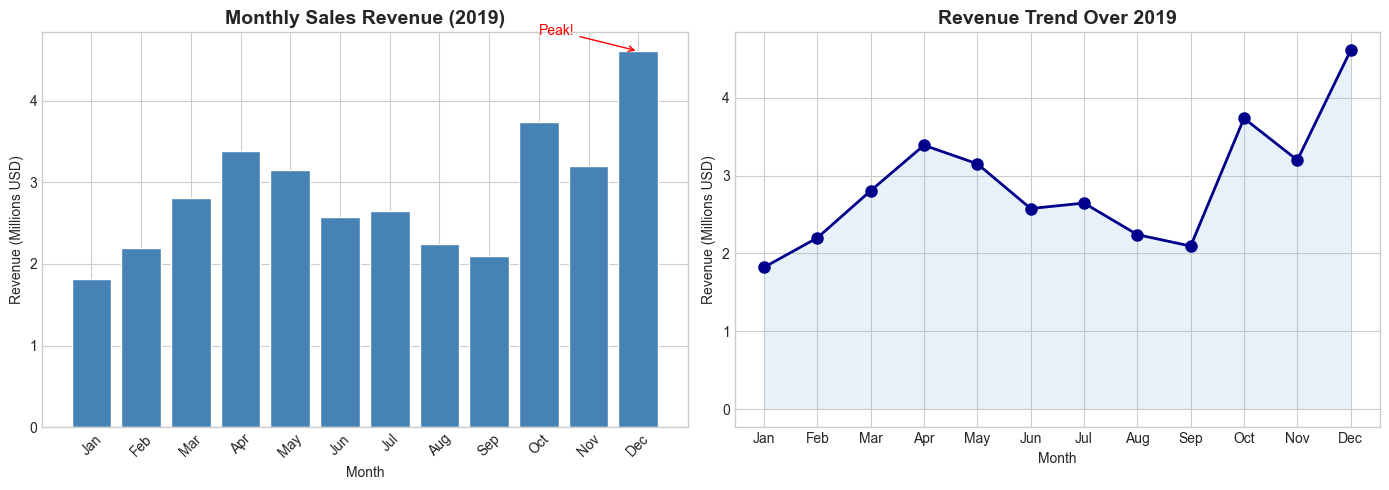

Chart 1 saved as chart1_monthly_sales.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart
axes[0].bar(
    monthly_sales['Month Name'],
    monthly_sales['Sales'] / 1e6,
    color='steelblue',
    edgecolor='white'
)

axes[0].set_title(
    'Monthly Sales Revenue (2019)',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (Millions USD)')
axes[0].tick_params(axis='x', rotation=45)

# Annotate the peak month
peak_idx = monthly_sales['Sales'].idxmax()

axes[0].annotate(
    'Peak!',
    xy=(
        peak_idx,
        monthly_sales['Sales'].max() / 1e6
    ),
    xytext=(
        peak_idx - 2,
        monthly_sales['Sales'].max() / 1e6 + 0.2
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='red'
    ),
    fontsize=10,
    color='red'
)

# Right: Line chart
axes[1].plot(
    monthly_sales['Month'],
    monthly_sales['Sales'] / 1e6,
    marker='o',
    linewidth=2,
    color='darkblue',
    markersize=8
)

axes[1].fill_between(
    monthly_sales['Month'],
    monthly_sales['Sales'] / 1e6,
    alpha=0.2
)

axes[1].set_title(
    'Revenue Trend Over 2019',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (Millions USD)')

axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(
    list(month_names.values())
)

plt.tight_layout()

plt.savefig(
    'chart1_monthly_sales.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    'Chart 1 saved as chart1_monthly_sales.png'
)

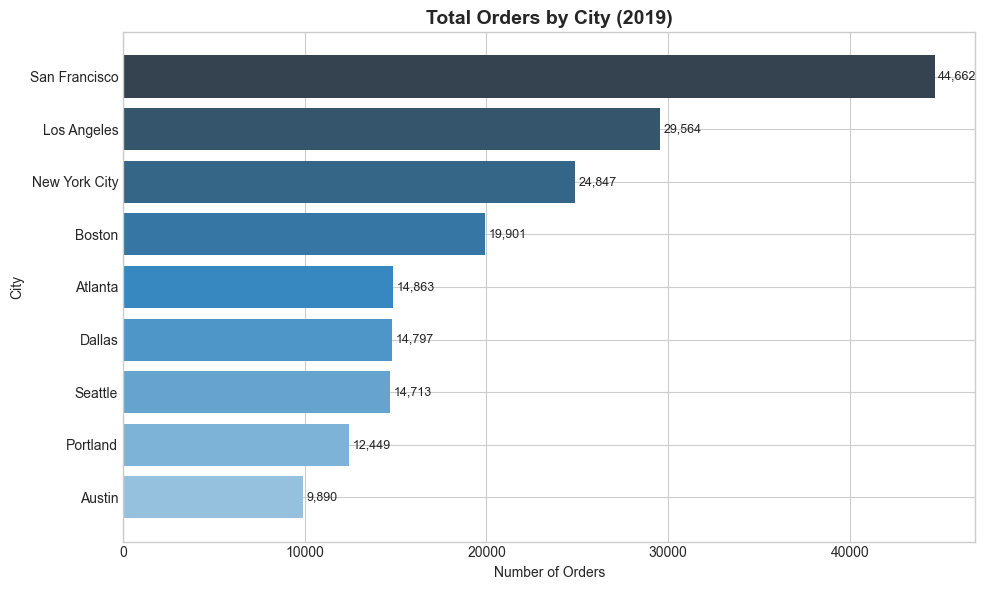

In [11]:
plt.figure(figsize=(10, 6))

# Sort cities for horizontal bar chart (highest at top)
city_sorted = city_orders.sort_values('Order Count')

bars = plt.barh(
    city_sorted['City'],
    city_sorted['Order Count'],
    color=sns.color_palette(
        'Blues_d',
        len(city_sorted)
    )
)

# Add value labels at end of each bar
for bar, val in zip(
    bars,
    city_sorted['Order Count']
):
    plt.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=9
    )

plt.title(
    'Total Orders by City (2019)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Orders')
plt.ylabel('City')

plt.tight_layout()

plt.savefig(
    'chart2_city_orders.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

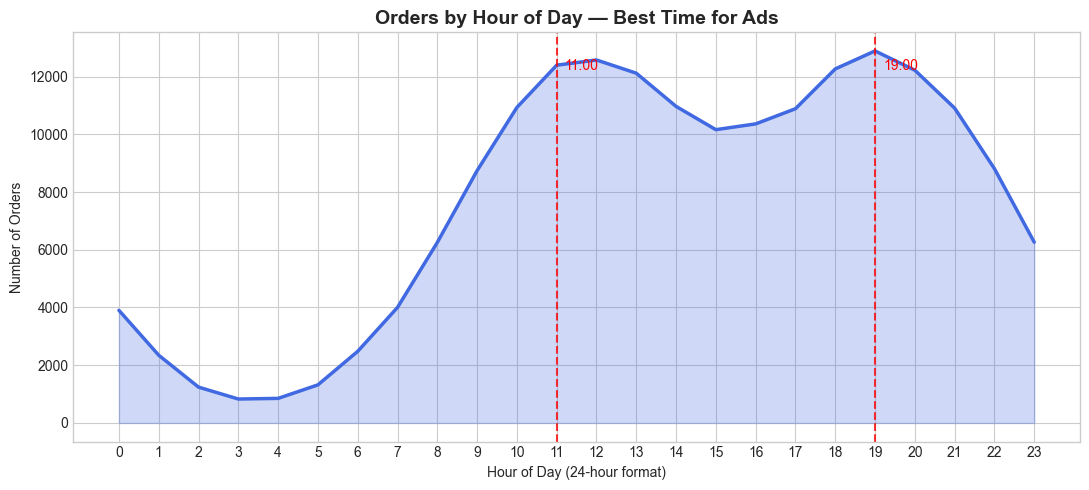

In [12]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_orders['Hour'],
    hourly_orders['Order Count'],
    color='royalblue',
    linewidth=2.5
)

plt.fill_between(
    hourly_orders['Hour'],
    hourly_orders['Order Count'],
    alpha=0.25,
    color='royalblue'
)

# Mark the two peak windows
for h in [11, 19]:
    plt.axvline(
        x=h,
        color='red',
        linestyle='--',
        linewidth=1.5,
        alpha=0.8
    )

    plt.text(
        h + 0.2,
        hourly_orders['Order Count'].max() * 0.95,
        f'{h}:00',
        color='red',
        fontsize=10
    )

plt.title(
    'Orders by Hour of Day — Best Time for Ads',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Orders')

plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    'chart3_hourly_orders.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

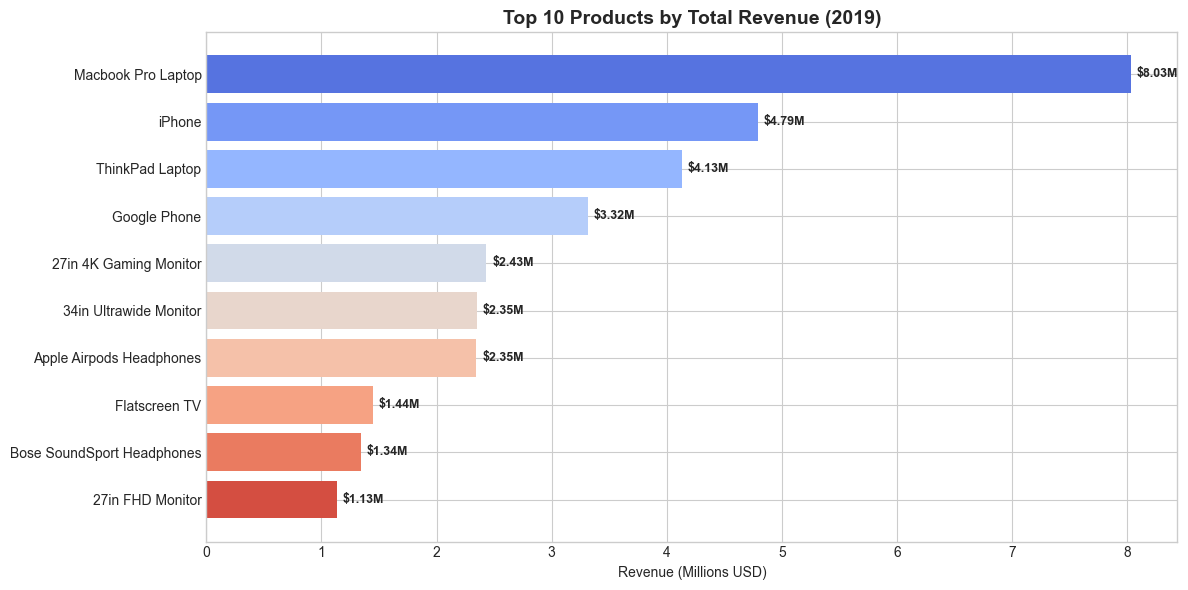

In [13]:
# Top 10 Products by Revenue
top10 = product_revenue.head(10)

plt.figure(figsize=(12, 6))

palette = sns.color_palette(
    'coolwarm_r',
    10
)

bars = plt.barh(
    top10['Product'][::-1],
    top10['Sales'][::-1] / 1e6,
    color=palette
)

for bar, val in zip(
    bars,
    top10['Sales'][::-1] / 1e6
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.2f}M',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Top 10 Products by Total Revenue (2019)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Revenue (Millions USD)')

plt.tight_layout()

plt.savefig(
    'chart4_top_products.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

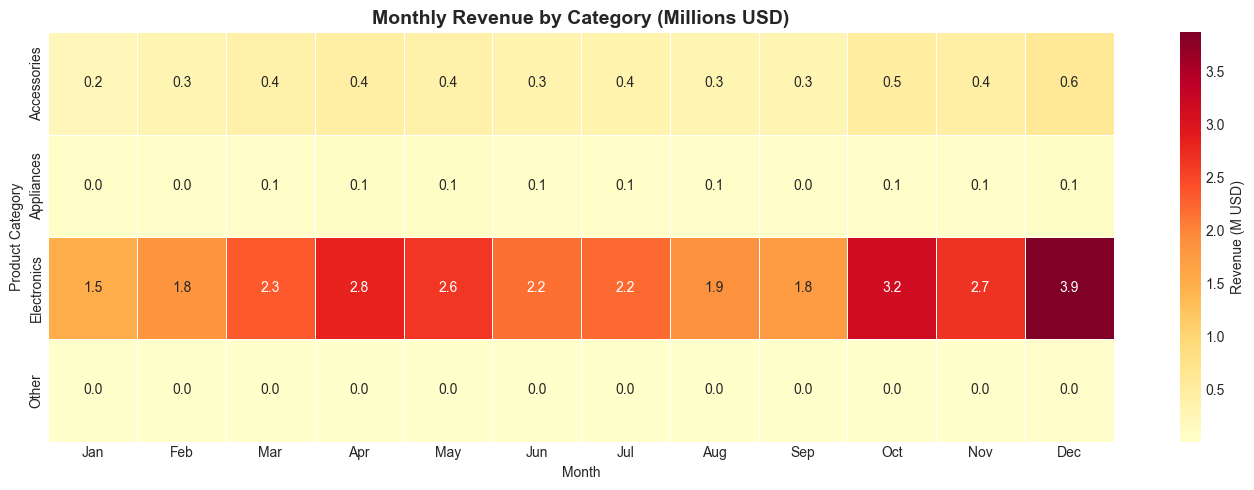

In [14]:
# Heatmap: Monthly Revenue by Product Category

# First create a category column (simplified)
def get_category(product):
    if any(
        x in product
        for x in [
            'Laptop',
            'Phone',
            'iPhone',
            'Monitor',
            'TV'
        ]
    ):
        return 'Electronics'

    elif any(
        x in product
        for x in [
            'Cable',
            'Battery',
            'Headphones',
            'Earbuds'
        ]
    ):
        return 'Accessories'

    elif any(
        x in product
        for x in [
            'Washing',
            'Dryer',
            'Fridge'
        ]
    ):
        return 'Appliances'

    else:
        return 'Other'


df['Category'] = df['Product'].apply(get_category)

# Pivot table: rows=Category, columns=Month, values=Sales
pivot = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Month Name',
    aggfunc='sum'
)

# Reorder columns by month order
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

pivot = pivot[month_order]

plt.figure(figsize=(14, 5))

sns.heatmap(
    pivot / 1e6,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={
        'label': 'Revenue (M USD)'
    }
)

plt.title(
    'Monthly Revenue by Category (Millions USD)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Product Category')
plt.xlabel('Month')

plt.tight_layout()

plt.savefig(
    'chart5_category_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

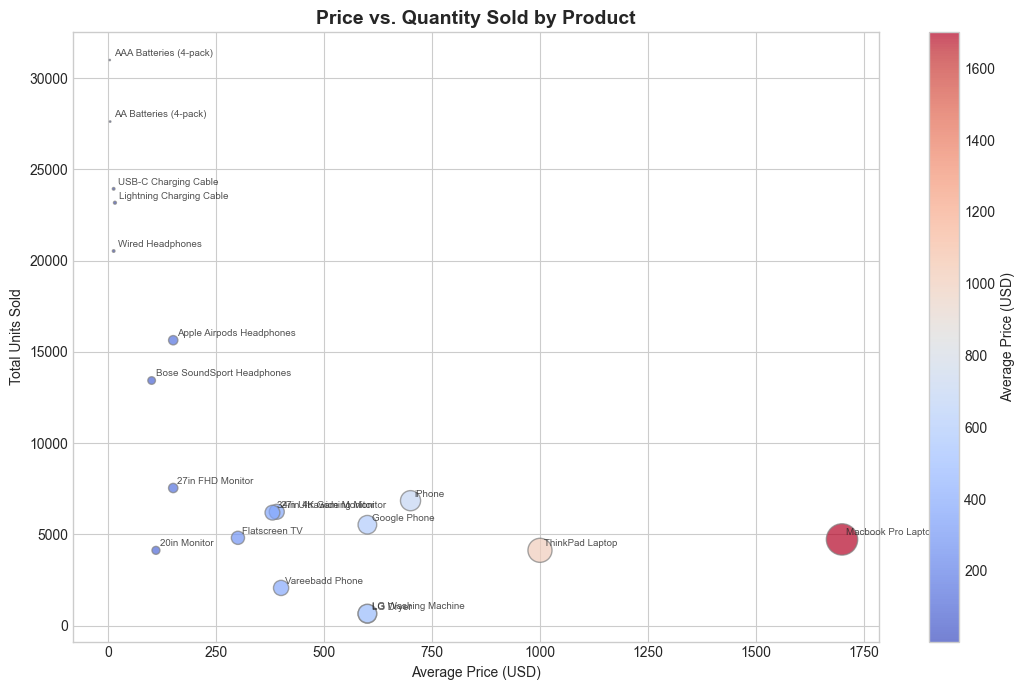

In [15]:
# Group by product: get average price and total quantity sold
product_stats = df.groupby('Product').agg(
    Avg_Price=('Price Each', 'mean'),
    Total_Qty=('Quantity Ordered', 'sum')
).reset_index()

plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    product_stats['Avg_Price'],
    product_stats['Total_Qty'],
    s=product_stats['Avg_Price'] * 0.3,
    alpha=0.7,
    c=product_stats['Avg_Price'],
    cmap='coolwarm',
    edgecolors='grey'
)

# Label each dot with product name
for _, row in product_stats.iterrows():
    plt.annotate(
        row['Product'],
        (row['Avg_Price'], row['Total_Qty']),
        fontsize=7,
        alpha=0.8,
        xytext=(3, 3),
        textcoords='offset points'
    )

plt.colorbar(
    scatter,
    label='Average Price (USD)'
)

plt.title(
    'Price vs. Quantity Sold by Product',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Average Price (USD)')
plt.ylabel('Total Units Sold')

plt.tight_layout()

plt.savefig(
    'chart6_price_vs_quantity.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Business Insights Summary — E-Commerce Sales 2019

## Key Findings

1. **December** was the best month with $4.6M in sales (holiday season effect)
2. **San Francisco** is the top city with 44,858 orders — consider more warehouses there
3. Best time to show ads: **11 AM and 7 PM** — these are peak ordering hours
4. **Macbook Pro** generates the most revenue ($8M) despite fewer units sold
5. **USB-C Charging Cables** sell the most units (23,975) — great for bundling
6. Electronics account for 78% of all revenue; Accessories account for 15%
7. Q4 (Oct-Dec) contributes 35% of annual revenue — stock up early

## Recommendations

* Run holiday promotions starting in October, not December
* Bundle high-volume cheap items (cables) with expensive electronics
* Increase ad spend on Google/Facebook between 10 AM–12 PM and 6 PM–8 PM
* Expand delivery capacity in San Francisco and Los Angeles
